In [14]:
# %pylab inline

In [15]:
# %pip install keras-unet

In [16]:
from keras_unet.models import custom_unet
from matplotlib import pyplot as plt
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import os
import numpy as np
import pandas as pd
from PIL import Image


In [17]:
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget http://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz


# from torchvision.datasets import OxfordIIITPet
# dataset = OxfordIIITPet( root="./data", split="trainval", target_types="segmentation", download=True)


# !wget https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/images.npz
# !wget https://github.com/DivyanshuTak/Ultrasoud_Unet_Segmentation/raw/refs/heads/main/masks.npz

526.00s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


--2026-04-01 05:47:07--  http://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz [following]
--2026-04-01 05:47:07--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-04-01 05:47:08--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [app

714.73s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


URL transformed to HTTPS due to an HSTS policy
--2026-04-01 05:50:16--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/annotations.tar.gz [following]
--2026-04-01 05:50:16--  https://thor.robots.ox.ac.uk/pets/annotations.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19173078 (18M) [application/octet-stream]
Saving to: ‘annotations.tar.gz.5’

annotations.tar.gz. 100%[===================>]  18.28M  3.98MB/s    in 4.8s    

2026-04-01 05:50:21 (3.81 MB/s) - ‘annotations.tar.gz.5’ saved [19173078/19173078]



In [26]:
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

1013.51s - pydevd: Sending message related to process being replaced timed-out after 5 seconds
1022.25s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


In [19]:
img_dir = './images'
mask_dir = './annotations/trimaps'
img_size = 320


images = []
masks = []


In [20]:
for filename in sorted(os.listdir(img_dir))[:200]:
    if not filename.endswith(".jpg"): 
        continue

    img_path = os.path.join(img_dir, filename)
    mask_name = os.path.splitext(filename)[0] + '.png'
    mask_path = os.path.join(mask_dir, mask_name)

    if not os.path.exists(mask_path):
        continue

    img = Image.open(img_path).convert('L').resize((320, 320))
    mask = Image.open(mask_path).convert('L').resize((320, 320))

    images.append(np.array(img))
    masks.append(np.array(mask))

images = np.array(images)
masks = np.array(masks)

masks = (masks == 1).astype(np.float32)  

("Loaded images:", images.shape, "masks:", masks.shape)

('Loaded images:', (197, 320, 320), 'masks:', (197, 320, 320))

In [21]:
X_train = images[:170][..., None]
y_train = masks[:170][..., None]
X_test = images[170:][..., None]
y_test = masks[170:][..., None]

print(X_train.shape, y_train.shape)

(170, 320, 320, 1) (170, 320, 320, 1)


In [22]:
#
# 2. NETWORK
#
model = custom_unet( input_shape=(320, 320, 1), dropout = 0.05)
model.compile( loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [23]:
#
# 3. TRAIN
#
callbacks = [
    ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min'),
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]

history = model.fit(X_train, y_train, validation_split=0.1, epochs=5, callbacks=callbacks, batch_size=32)

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5630 - loss: 0.8391

5/5 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step - accuracy: 0.5812 - loss: 0.8019 - val_accuracy: 0.6465 - val_loss: 1.0994
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.6624 - loss: 0.6773 - val_accuracy: 0.5944 - val_loss: 2.1416
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.7279 - loss: 0.6209 - val_accuracy: 0.4037 - val_loss: 10.3079
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.7597 - loss: 0.5773 - val_accuracy: 0.3570 - val_loss: 79.7645
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 27s 5s/step - accuracy: 0.7655 - loss: 0.5566 - val_accuracy: 0.6528 - val_loss: 2.6502


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


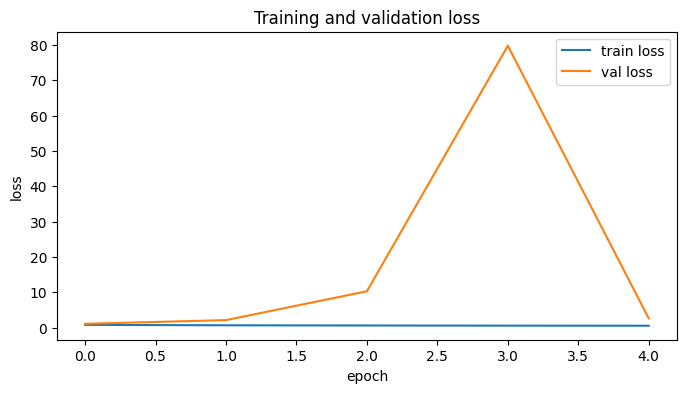

In [24]:
#
# 4. PREDICT
#

y_pred = model.predict(X_test)
plt.figure(figsize=(8, 4))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')

plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Training and validation loss')

plt.show()


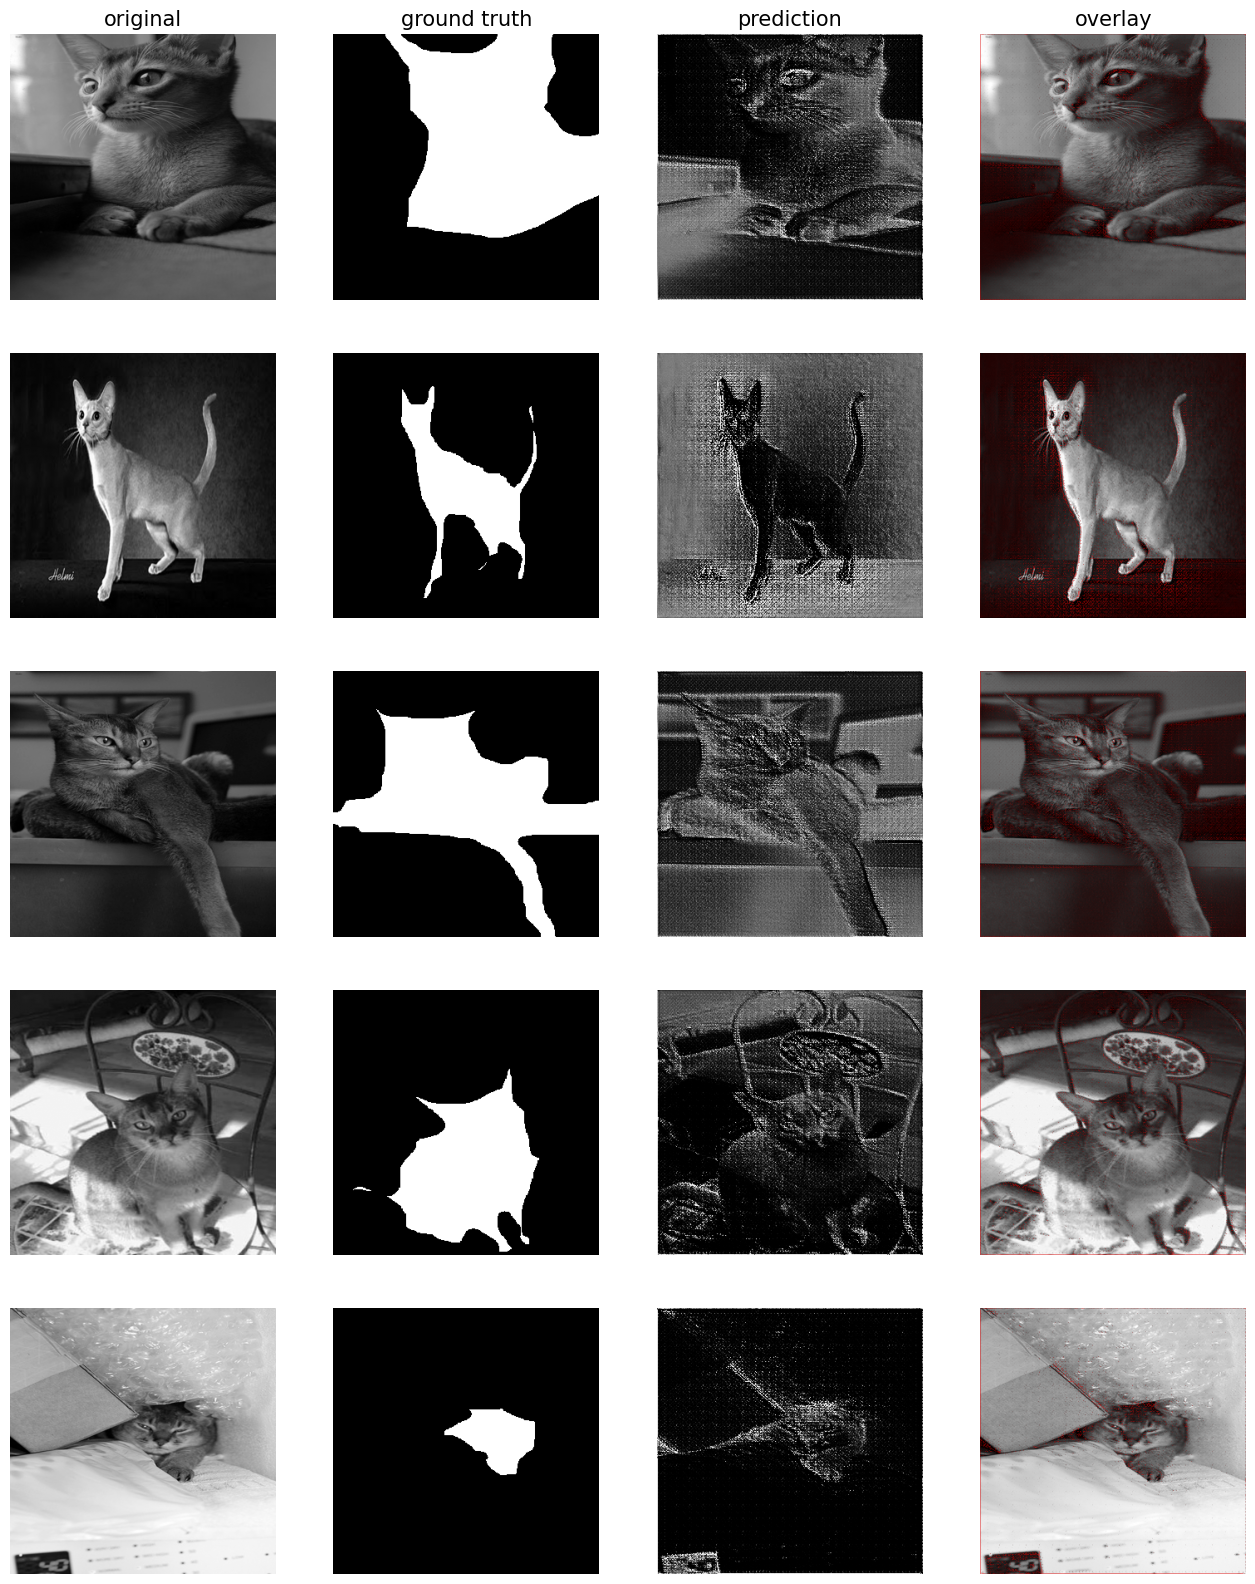

In [25]:
from keras_unet.utils import plot_imgs

plot_imgs(org_imgs=X_test, mask_imgs=y_test, pred_imgs=y_pred, nm_img_to_plot=5)